# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1 Coleta de Dados

In [2]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# 2 Verificação Inicial


## 2.1 Tipos de Dados

In [3]:
# Verificando a quantidade de linhas e colunas
df.shape

(164, 8)

In [4]:
# Verificando os tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    str    
 2   Income              164 non-null    str    
 3   Education           164 non-null    str    
 4   Marital Status      164 non-null    str    
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    str    
 7   Credit Score        164 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 10.4 KB


In [5]:
df.isnull().sum()

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64

A variável **'Age'** representa idade, então o tipo mais adequado seria inteiro. Porém, como a coluna possui 34 valores faltantes, ela permanece temporariamente como float64. Após o tratamento dos dados ausentes, a coluna poderá ser convertida para inteiro.

A variável **'Income'** representa a renda e está como tipo str, então para uma melhor análise é necessário transforma-lo em float64.

In [6]:
# Removendo os pontos da coluna 'Income'
df['Income'] = df['Income'].str.replace(',', '', regex=False)

# Convertendo a coluna 'Income' de str para float64
df['Income'] = df['Income'].astype(float)

In [7]:
# Verificando se houve a conversão
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    str    
 2   Income              164 non-null    float64
 3   Education           164 non-null    str    
 4   Marital Status      164 non-null    str    
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    str    
 7   Credit Score        164 non-null    str    
dtypes: float64(2), int64(1), str(5)
memory usage: 10.4 KB


## 2.2 Dados faltantes.

Como visto anteriormente, existem **34 valores faltantes** na variável **'Age'**, logo iremos verificar a proporção destes valores no dataset. 

In [8]:
(df['Age'].isnull().sum() / len(df)) * 100

np.float64(20.73170731707317)

Como os valores ausentes da coluna **'Age'** aproximadamente representa **21%** dos dados a melhor forma de tratá-lo é substituindo os valores NaN pela a mediana. Foi escolhido a mediana porque os dados vão ser convertidos em inteiro.

In [9]:
# Substituindo os dados ausentes pela a mediana
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

In [10]:
# Verificando se a substituição funcionou
df.isnull().sum()

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64

In [11]:
# Convertendo o tipo de dados da coluna 'Age' para inteiro
df['Age'] = df['Age'].astype(int)

In [12]:
# Verificando se a conversão funcionou
df.dtypes

Age                     int64
Gender                    str
Income                float64
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

## 2.3 Verificação e padronização das variáveis categóricas

In [13]:
# Verifica os tipos únicos do dataset
for column in df:
    if df[column].dtype == 'str':
        print("\n", column, ":", df[column].unique())
        df[column].unique()


 Gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str

 Education : <StringArray>
[  'Bachelor's Degree',     'Master's Degree',           'Doctorate',
 'High School Diploma',  'Associate's Degree']
Length: 5, dtype: str

 Marital Status : <StringArray>
['Single', 'Married']
Length: 2, dtype: str

 Home Ownership : <StringArray>
['Rented', 'Owned']
Length: 2, dtype: str

 Credit Score : <StringArray>
['High', 'Average', 'Low']
Length: 3, dtype: str


In [14]:
# Substituição dos valores das colunas de inglês para português para melhor visualização nos gráficos
df["Gender"] = df["Gender"].map({
    "Female": "Feminino",
    "Male": "Masculino"})

df["Education"] = df["Education"].map({
    "High School Diploma": "Ensino Médio",
    "Associate's Degree": "Curso Técnico",
    "Bachelor's Degree": "Bacharelado",
    "Master's Degree": "Mestrado",
    "Doctorate": "Doutorado"})

df["Marital Status"] = df["Marital Status"].map({
    "Single": "Solteiro(a)",
    "Married": "Casado(a)"})

df["Home Ownership"] = df["Home Ownership"].map({
    "Rented": "Alugado",
    "Owned": "Próprio"})

df["Credit Score"] = df["Credit Score"].map({
    "High": "Alto",
    "Average": "Médio",
    "Low": "Baixo"})
    

In [15]:
# Verifica se a substituição funcionou
for column in df:
    if df[column].dtype == 'str':
        print("\n", column, ":", df[column].unique())
        df[column].unique()


 Gender : <StringArray>
['Feminino', 'Masculino']
Length: 2, dtype: str

 Education : <StringArray>
['Bacharelado', 'Mestrado', 'Doutorado', 'Ensino Médio', 'Curso Técnico']
Length: 5, dtype: str

 Marital Status : <StringArray>
['Solteiro(a)', 'Casado(a)']
Length: 2, dtype: str

 Home Ownership : <StringArray>
['Alugado', 'Próprio']
Length: 2, dtype: str

 Credit Score : <StringArray>
['Alto', 'Médio', 'Baixo']
Length: 3, dtype: str


Após a análise dos valores únicos, não foram identificadas inconsistências de digitação nas variáveis categóricas. Posteriormente, os rótulos foram padronizados e traduzidos para português com o objetivo de facilitar a visualização dos gráficos e a interpretação dos resultados.

# 3. Análise Exploratória dos Dados

## 3.1 Análise Univariada 

### 3.1.1 Variáveis Numéricas

In [16]:
# Verifica dados estatíticos das variáveis numéricas
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.195122,83.765244,0.652439
std,7.586619,32.457307,0.883346
min,25.000000,25.000000,0.000000
25%,31.750000,57.500000,0.000000
50%,36.000000,83.750000,0.000000
75%,43.000000,105.000000,1.000000
max,53.000000,162.500000,3.000000


In [17]:
# Na estatística uma dispersão é considerada baixa, moderada ou alta a partir do seu coeficiente de variação (CV), que é o desvio padrão 
# dividido pela a média:
# CV <= 10% -> dispersão baixa
# 10% < CV <= 30% -> dispersão moderada
# CV > 30% -> dispersão alta

# logo vamos calcular o CV de cada variável numérica.

numerical_variables = ["Age", "Income", "Number of Children"]

for column in numerical_variables:
    coefficient_of_variation = (df[column].std() / df[column].mean()) * 100
    print(f"Coeficiente de variação da variável {column}: {coefficient_of_variation:.2f}")

Coeficiente de variação da variável Age: 20.40
Coeficiente de variação da variável Income: 38.75
Coeficiente de variação da variável Number of Children: 135.39


É possível perceber na tabela describe() que:

- A variável idade possuii média de **37.19** e a mediana de **36**, com uma pequena diferença, o que sugere que os dados estão mais próximo de uma curva normal, indicando distribuição de idade relativamente equilibrada, sem forte assimetria.
- Metade das pessoas tem entre **31,75** e **43** anos e a idade mínima é **25** e a máxima **53**, então o grupo parece concentrado em adultos de faixa etária intermediária.
- Pelo critério do IQR, não há indício forte de outliers em Age.
- A coluna **'Income'** varia de 25 a 162.5, indicando grande heterogeneidade na renda.
- Na variável **'Income'** mostra que a média de **83,77** e mediana de **83.75** são quase iguais, se comportando como uma curva normal, isso sugere a dispersão está bem centrada, sem grande distorção para um dos lados.
- O CV de variação da **'Income'** é de **38.75**, relavitamente alta, indicando bastante variação de renda entre os individuos.
- Não evidências clara de outliers extremos na varoável **'Income'**.
- A variável **'Number of Childrem'** tem mediana **0** e média aproximada de **0.65**, isso indica que mais da metade das pessoas não tem filhos. O valor máximo é **3**, o que mostra que existem poucos casos com mais filhos. Essa variável parece assimétrica à direita, porque muitos valores estão em **0** e poucos valores maiores puxam a média para cima. Pelo IQR, o valor **3** pode ser considerado um possível outlier

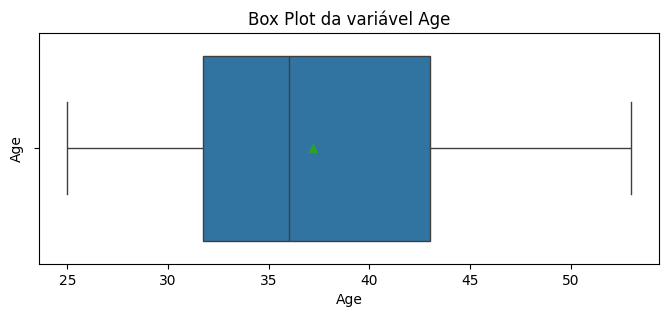

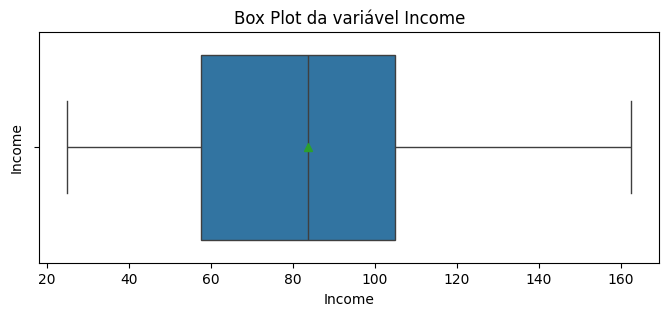

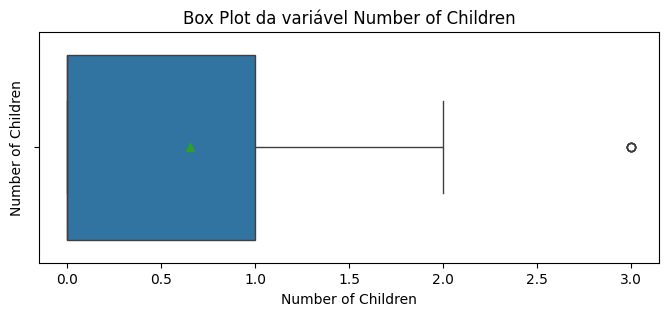

In [18]:
# Boxplot das variáveis numéricas
numerical_cols = ['Age', 'Income', 'Number of Children']

for col in numerical_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col], showmeans=True)
    plt.title(f'Box Plot da variável {col}')
    plt.ylabel(col)
    plt.show()

Pelos boxplots, não há evidência de outliers relevantes em **Age** e **Income**. Já na variável **Number of Children**, o valor **3** aparece como **possível outlier** pelo critério do boxplot. No entanto, como essa variável é discreta e o valor ainda é plausível no contexto do problema, optei por não realizar tratamento, apenas registrar essa observação.

### 3.1.2 Variáveis Categóricas

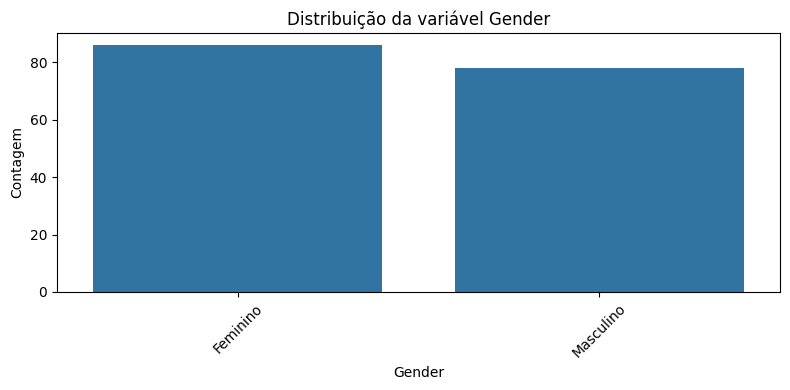


Percentual de Gender:
Gender
Feminino     52.44
Masculino    47.56
Name: proportion, dtype: float64


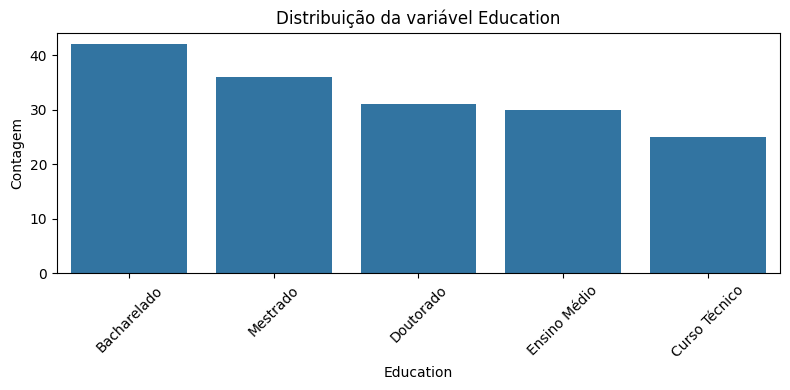


Percentual de Education:
Education
Bacharelado      25.61
Mestrado         21.95
Doutorado        18.90
Ensino Médio     18.29
Curso Técnico    15.24
Name: proportion, dtype: float64


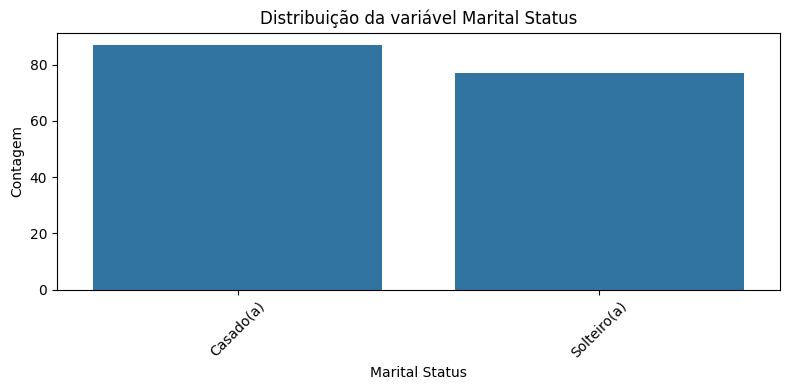


Percentual de Marital Status:
Marital Status
Casado(a)      53.05
Solteiro(a)    46.95
Name: proportion, dtype: float64


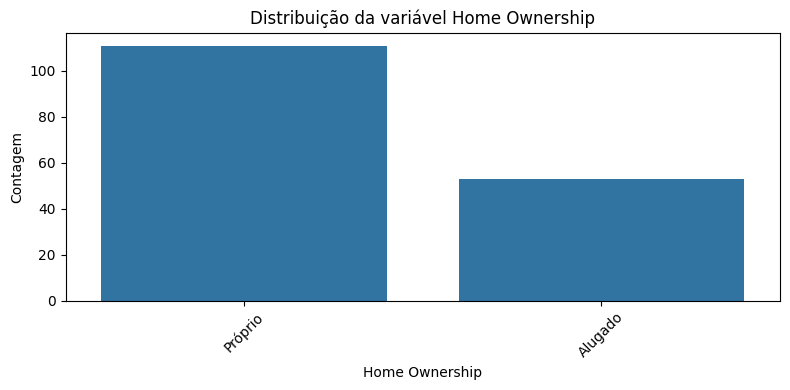


Percentual de Home Ownership:
Home Ownership
Próprio    67.68
Alugado    32.32
Name: proportion, dtype: float64


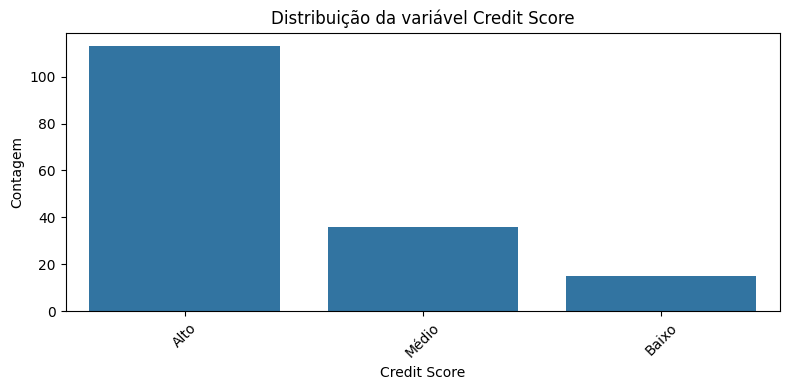


Percentual de Credit Score:
Credit Score
Alto     68.90
Médio    21.95
Baixo     9.15
Name: proportion, dtype: float64


In [19]:
categorical_cols = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Distribuição da variável {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Contagem')
    plt.tight_layout()
    plt.show()

    print(f'\nPercentual de {col}:')
    print((df[col].value_counts(normalize=True) * 100).round(2))

As variáveis categóricas mostram como os clientes estão distribuídos entre **gênero, escolaridade**, **estado civil**, **condição do imóvel** e **score de crédito**:

* Observa-se que a variável **Gender** está relativamente equilibrada, com leve predominância do gênero feminino **(52,44%)** em relação ao masculino **(47,56%)**.
* Na variável **Education**, a categoria mais frequente é Bacharelado **(25,61%)**, seguida por **Mestrado (21,95%)**. Já **Curso Técnico** aparece como a menos frequente **(15,24%)**. Isso sugere uma base com concentração maior em níveis mais altos de escolaridade.
* Em **Marital Status**, a distribuição também é equilibrada, com pequena predominância de **Casado(a) (53,05%)** em relação a **Solteiro(a) (46,95%)**.
* Já na variável **Home Ownership**, a maioria dos clientes possui **imóvel Próprio (67,68%)**, enquanto **32,32%** moram em imóvel **Alugado**. Isso indica predominância de clientes com casa própria na base analisada.
* A análise dessas variáveis ajuda a compreender melhor o perfil predominante dos clientes antes de avançar para as relações bivariadas.

## 3.2 Análise Bivariada 

Perguntas de partida e hipóteses:

* Existe relação entre a idade e o status civil?
* Qual a relação entre o score de crédito e o nível de escolaridade?
* O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?

### 3.2.1 Existe relação entre a idade e o status civil?

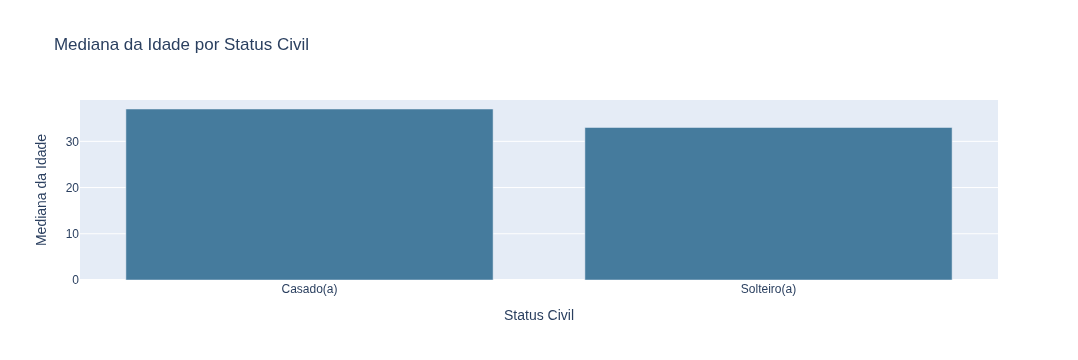

In [20]:
# Calculando a média de Idade por Status Civil
median_age_by_marital_status = df.groupby('Marital Status')['Age'].median().reset_index()

# Criar gráfico de barras
fig = px.bar(
    median_age_by_marital_status,
    x='Marital Status',
    y='Age',
    title='Mediana da Idade por Status Civil',
    labels={'Age': 'Mediana da Idade', 'Marital Status': 'Status Civil'},
    color_discrete_sequence=['#457b9d']
)

fig.show()

Observa-se que clientes casados tendem a apresentar idade mediana maior do que clientes solteiros, sugerindo associação entre idade e status civil.

### 3.2.2 Qual a relação entre o score de crédito e o nível de escolaridade?

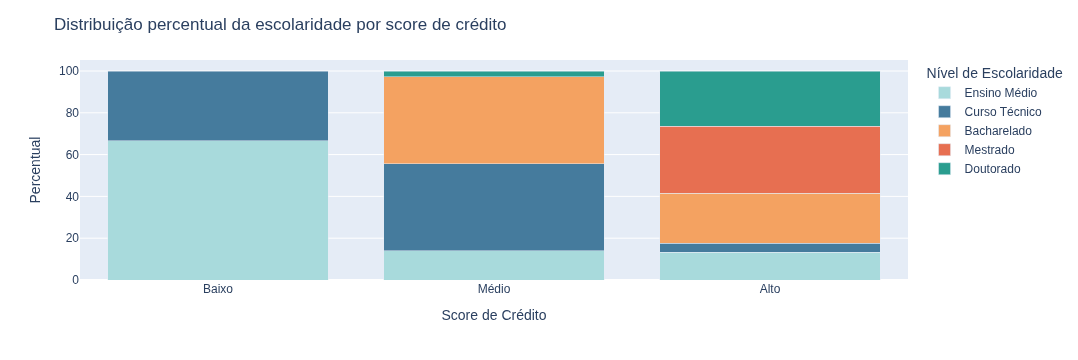

In [21]:
order_credit_score = ['Baixo', 'Médio', 'Alto']
order_education = ['Ensino Médio', 'Curso Técnico', 'Bacharelado', 'Mestrado', 'Doutorado']

# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['Credit Score', 'Education']).size().reset_index(name='count')
total_por_credit_score = df_grouped.groupby('Credit Score')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_credit_score) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Credit Score', y='percent', color='Education', barmode='stack',
             category_orders={"Credit Score": order_credit_score, 'Education': order_education},
             labels={'Credit Score': 'Score de Crédito', 'percent': 'Percentual', 'Education': 'Nível de Escolaridade'},
             color_discrete_sequence=['#a8dadc', '#457b9d', '#f4a261', '#e76f51', '#2a9d8f'])

fig.update_layout(title='Distribuição percentual da escolaridade por score de crédito',
                  xaxis_title='Score de Crédito',
                  yaxis_title='Percentual',
                  legend_title='Nível de Escolaridade')
fig.show()

O gráfico mostra a distribuição percentual dos níveis de escolaridade dentro de cada faixa de score de crédito. Observa-se que o score Baixo está mais concentrado entre clientes com Ensino Médio e Curso Técnico, enquanto o score Alto apresenta maior participação de níveis de escolaridade mais elevados, como Bacharelado, Mestrado e Doutorado. Já o score Médio aparece com distribuição intermediária. Esses resultados sugerem uma associação entre escolaridade e score de crédito, embora essa análise, por si só, não permita afirmar causalidade.


### 3.2.3 O salário parece influenciar na idade?

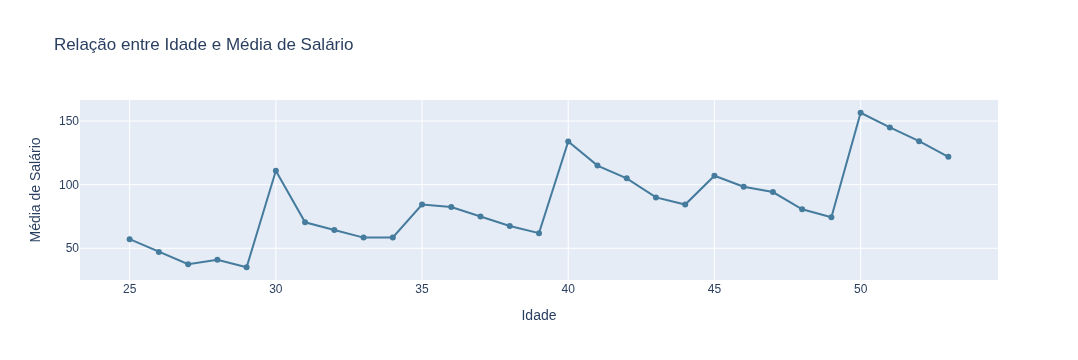

In [22]:
average_salary_by_age = df.groupby('Age')['Income'].mean().reset_index()

fig = px.line(
    average_salary_by_age.round(2),
    x='Age',
    y='Income',
    markers=True,
    title='Relação entre Idade e Média de Salário',
    labels={'Age': 'Idade', 'Income': 'Média de Salário'},
    color_discrete_sequence=['#457b9d']
)

fig.show()

O gráfico sugere uma tendência geral de aumento da renda em faixas etárias mais altas, embora haja oscilações entre as idades. Isso indica uma possível associação positiva entre idade e salário, mas a relação não parece perfeitamente linear. Como a análise foi feita com médias por idade, parte dessas variações pode estar relacionada à quantidade de observações em cada grupo etário.

### 3.2.4 Existe relação entre salário e Score de Crédito?

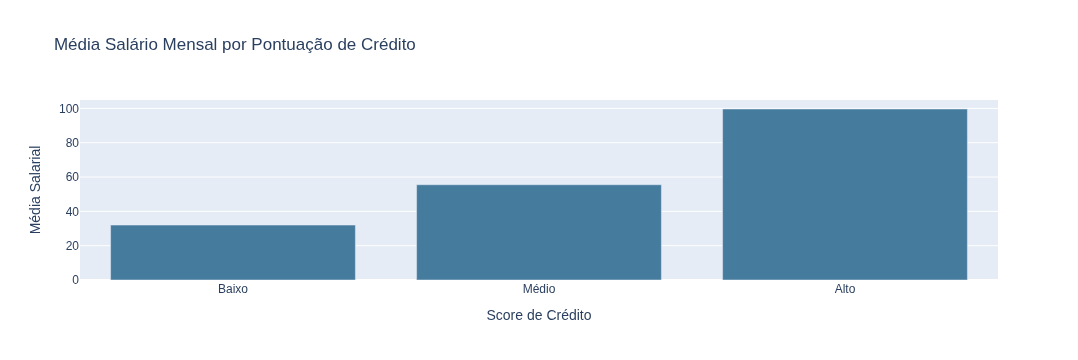

In [23]:
order_credit_score = ['Baixo', 'Médio', 'Alto']

average_income_by_credit_score = df.groupby('Credit Score')['Income'].mean().reset_index()
fig = px.bar(average_income_by_credit_score,
             x='Credit Score',
             y='Income',
             category_orders={"Credit Score": order_credit_score},
             title='Média Salário Mensal por Pontuação de Crédito',
             color_discrete_sequence=['#457b9d'],
             labels={'Credit Score': 'Score de Crédito', 'Income': 'Média Salarial'})
fig.show()

Observa-se uma associação positiva entre renda média e score de crédito, já que as categorias com score mais alto apresentam maiores valores médios de salário. Isso sugere que renda pode estar relacionada a melhores pontuações de crédito, embora essa análise não permita concluir causalidade.

### 3.2.5 Clientes com casa própria tendem a ter um score mais alto?

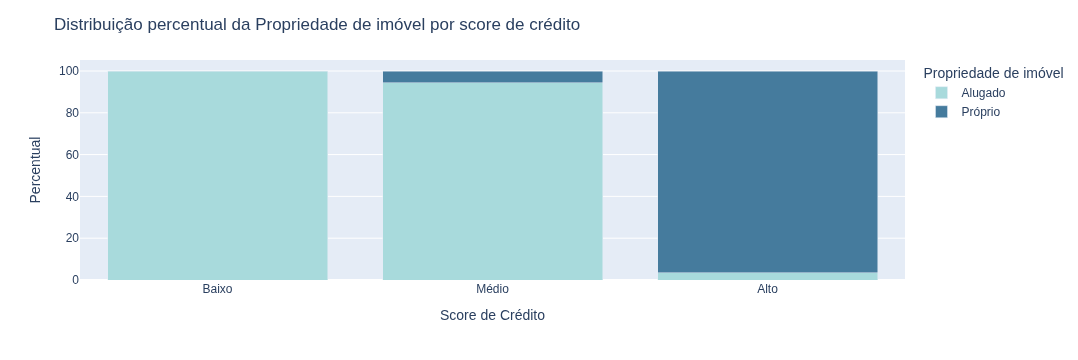

In [24]:
order_credit_score = ['Baixo', 'Médio', 'Alto']

# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['Credit Score', 'Home Ownership']).size().reset_index(name='count')
total_por_credit_score = df_grouped.groupby('Credit Score')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_credit_score) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Credit Score', y='percent', color='Home Ownership', barmode='stack',
             category_orders={"Credit Score": order_credit_score},
             labels={'Credit Score': 'Score de Crédito', 'percent': 'Percentual', 'Home Ownership': 'Propriedade de imóvel'},
             color_discrete_sequence=['#a8dadc', '#457b9d'])

fig.update_layout(title='Distribuição percentual da Propriedade de imóvel por score de crédito',
                  xaxis_title='Score de Crédito',
                  yaxis_title='Percentual',
                  legend_title='Propriedade de imóvel')
fig.show()

Em termos percentuais, clientes com imóvel próprio concentram maior participação no score Alto, enquanto clientes com imóvel alugado aparecem relativamente mais nas faixas Baixo e Médio. Isso sugere associação entre condição do imóvel e score de crédito na base analisada.

### 3.2.6 Qual a relação entre Gênero e score de crédito?

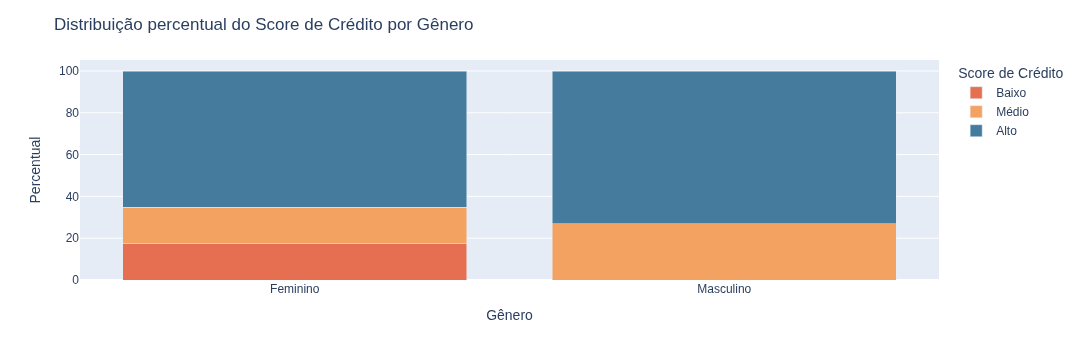

In [25]:
order_credit_score = ['Baixo', 'Médio', 'Alto']

# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['Gender', 'Credit Score']).size().reset_index(name='count')
total_por_credit_score = df_grouped.groupby('Gender')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_credit_score) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Gender', y='percent', color='Credit Score', barmode='stack',
             category_orders={"Credit Score": order_credit_score},
             labels={'Credit Score': 'Score de Crédito', 'percent': 'Percentual', 'Gender': 'Gênero'},
             color_discrete_sequence=['#e76f51', '#f4a261', '#457b9d'])

fig.update_layout(title='Distribuição percentual do Score de Crédito por Gênero',
                  xaxis_title='Gênero',
                  yaxis_title='Percentual',
                  legend_title='Score de Crédito')
fig.show()

O gráfico mostra a distribuição percentual do score de crédito dentro de cada gênero. Observa-se que a composição percentual é relativamente semelhante entre feminino e masculino, sem diferenças muito acentuadas entre as faixas Baixo, Médio e Alto. Isso sugere que, nesta base, o gênero não parece estar fortemente associado ao score de crédito.

### 3.2.7 Existe relação entre quantidade de filhos e pontuação de crédito?

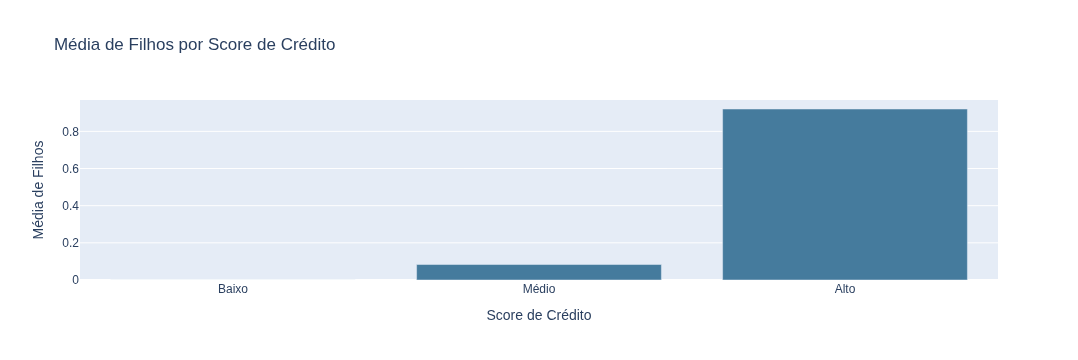

In [26]:
order_credit_score = ['Baixo', 'Médio', 'Alto']

average_children_by_credit_score = df.groupby('Credit Score')['Number of Children'].mean().reset_index()

fig = px.bar(
    average_children_by_credit_score,
    x='Credit Score',
    y='Number of Children',
    category_orders={'Credit Score': order_credit_score},
    title='Média de Filhos por Score de Crédito',
    labels={
        'Credit Score': 'Score de Crédito',
        'Number of Children': 'Média de Filhos'
    },
    color_discrete_sequence=['#457b9d']
)

fig.show()

O gráfico sugere que clientes com score de crédito mais alto apresentam, em média, maior quantidade de filhos. No entanto, essa relação deve ser interpretada com cautela, pois a diferença pode estar associada a outros fatores, como idade, renda e estado civil.

### 3.2.8 Existe relação entre gênero e nível de escolaridade?

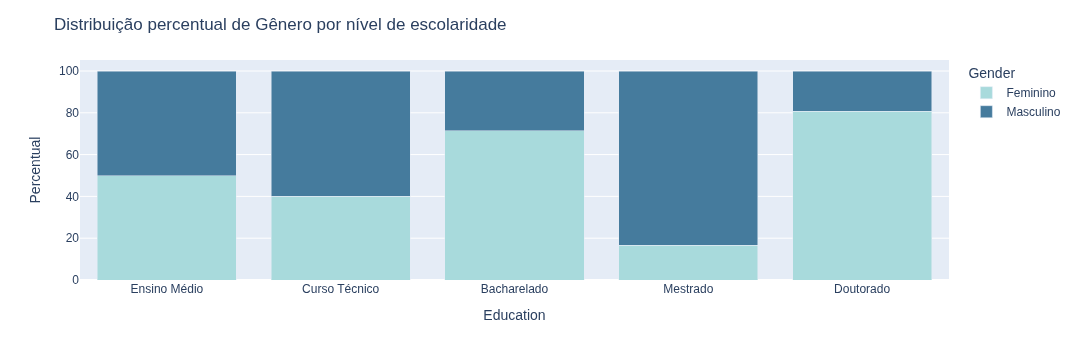

In [27]:
order_education = ["Ensino Médio", "Curso Técnico", "Bacharelado", "Mestrado", "Doutorado"]

# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['Education', 'Gender']).size().reset_index(name='count')
total_por_education = df_grouped.groupby('Education')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_education) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Education', y='percent', color='Gender', barmode='stack',
             category_orders={"Education": order_education},
             labels={'Education': 'Nível de escolaridade', 'percent': 'Percentual', 'Gender': 'Gênero'},
             color_discrete_sequence=['#a8dadc', '#457b9d'])

fig.update_layout(title='Distribuição percentual de Gênero por nível de escolaridade',
                  xaxis_title='Education',
                  yaxis_title='Percentual',
                  legend_title='Gender')
fig.show()

O gráfico mostra a distribuição percentual de gênero dentro de cada nível de escolaridade. Observa-se que a composição entre feminino e masculino varia entre as categorias: Curso Técnico e Mestrado apresentam maior participação do gênero masculino, enquanto Bacharelado e Doutorado mostram maior participação do gênero feminino. Já em Ensino Médio, a distribuição é mais equilibrada. Esses resultados sugerem uma associação entre gênero e escolaridade na base analisada, embora essa análise não permita afirmar causalidade.

# 4. Correlação, tratamento das variáveis categóricas, divisão treino/teste e balanceamento

## 4.1 Ánalise de correlação

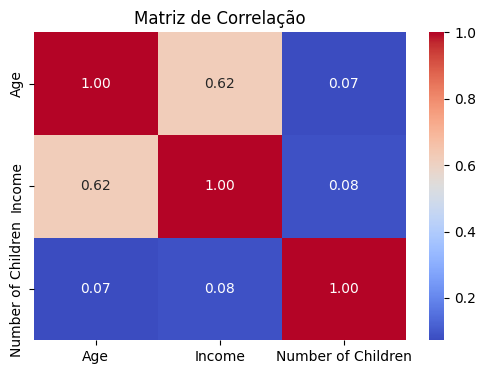

In [28]:
numerical_correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(6, 4))
sns.heatmap(numerical_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Foi observada uma correlação positiva moderada entre **Age** e **Income** (0,62), o que faz sentido, pois pessoas mais velhas podem ter maior tempo de experiência profissional e, consequentemente, renda mais elevada. Já a variável **Number of Children** apresentou correlação fraca com as demais.

## 4.2 Tratamento das variáveis categóricos

Existem 5 variáveis categóricas

* Gender – One-Hot Encoding
* Education – mapeamento manual ordinal
* Marital Status – One-Hot Encoding
* Home Ownership – One-Hot Encoding
* Credit Score – mapeamento manual ordinal

In [29]:
# Mapeamento manual das variáveis ordinais
df['Education_encoded'] = df['Education'].map({
    'Ensino Médio': 0,
    'Curso Técnico': 1,
    'Bacharelado': 2,
    'Mestrado': 3,
    'Doutorado': 4
})

df['credit_score_encoded'] = df['Credit Score'].map({
    'Baixo': 0,
    'Médio': 1,
    'Alto': 2
})

# One-hot encoding nas variáveis nominais
df = pd.get_dummies(df, columns=['Gender', 'Marital Status', 'Home Ownership'], drop_first=True)

# Removendo colunas categóricas originais
df = df.drop(columns=['Education', 'Credit Score'])

# Convertendo booleanas em inteiras
bool_columns = df.select_dtypes(include='bool').columns
df[bool_columns] = df[bool_columns].astype(int)

df.head()

,Age,Income,Number of Children,Education_encoded,credit_score_encoded,Gender_Masculino,Marital Status_Solteiro(a),Home Ownership_Próprio
0,25,50.0,0,2,2,0,1,0
1,30,100.0,2,3,2,1,0,1
2,35,75.0,1,4,2,0,0,1
3,40,125.0,0,0,2,1,1,1
4,45,100.0,3,2,2,0,0,1


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         164 non-null    int64  
 1   Income                      164 non-null    float64
 2   Number of Children          164 non-null    int64  
 3   Education_encoded           164 non-null    int64  
 4   credit_score_encoded        164 non-null    int64  
 5   Gender_Masculino            164 non-null    int64  
 6   Marital Status_Solteiro(a)  164 non-null    int64  
 7   Home Ownership_Próprio      164 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 10.4 KB


Como a base possui várias variáveis categóricas, foi necessário transformá-las em formato numérico para permitir análises posteriores, como correlação e divisão entre treino e teste.

Nas variáveis Education e Credit Score, foi utilizado mapeamento manual, pois ambas possuem uma ordem natural entre as categorias. Dessa forma, a codificação respeita a progressão lógica dos níveis de escolaridade e das classes do score de crédito.

Já nas variáveis Gender, Marital Status e Home Ownership, foi utilizado One-Hot Encoding, por se tratarem de categorias nominais, sem hierarquia entre os valores.

Após o tratamento, as colunas categóricas originais em texto foram removidas, mantendo apenas as variáveis numéricas resultantes da transformação.

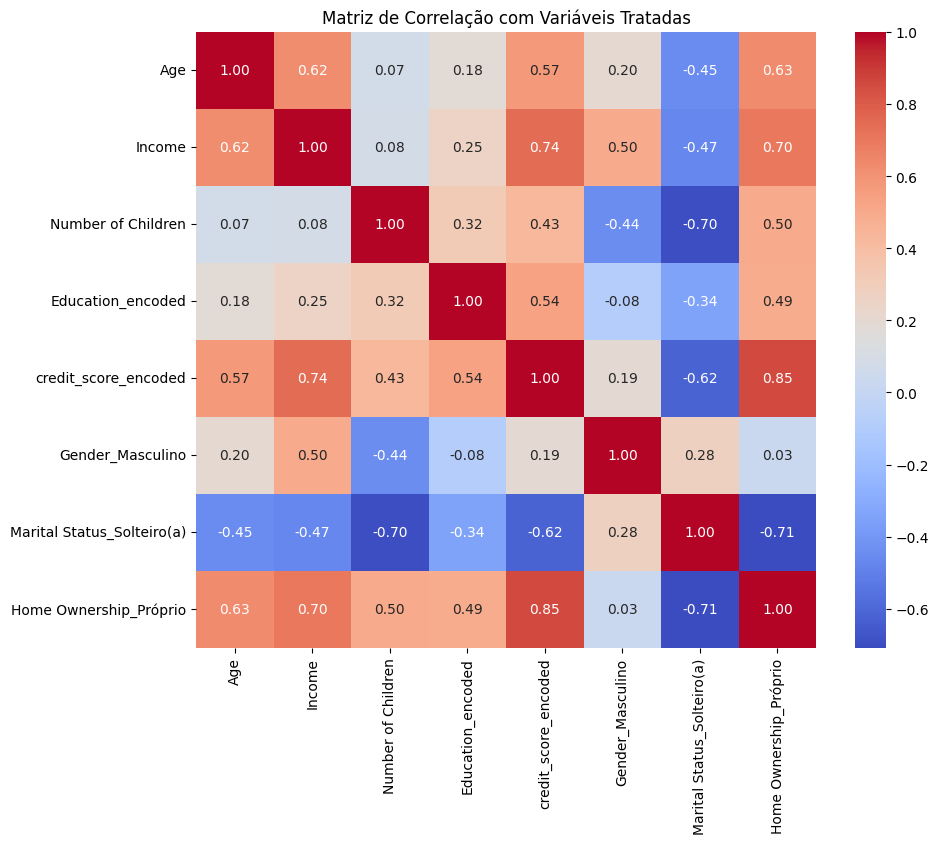

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação com Variáveis Tratadas')
plt.show()

Após o tratamento das variáveis categóricas, a nova matriz de correlação mostrou associações mais claras com a variável alvo credit_score_encoded. As correlações mais fortes foram observadas com home_ownership_Próprio (0,85) e Income (0,74), indicando que possuir imóvel próprio e ter maior renda estão associados a scores de crédito mais altos. Também foram observadas correlações moderadas com Age (0,57), Education_encoded (0,54) e Number of Children (0,43). Já a variável Marital Status_Solteiro(a) apresentou correlação negativa forte (-0,62), sugerindo que indivíduos solteiros tendem a estar associados a scores mais baixos. A variável Gender_Masculino apresentou correlação fraca (0,19), indicando baixa associação linear com o score de crédito.

Entre as variáveis explicativas, também se destacam as correlações entre Income e home_ownership_Próprio (0,70), Marital Status_Solteiro(a) e home_ownership_Próprio (-0,71), além de Age e Income (0,62). Esses resultados sugerem que o score de crédito parece ser influenciado por um conjunto de fatores socioeconômicos combinados, e não apenas por uma variável isolada.

## 4.3 Separação da base em treino e teste

In [32]:
# Definindo variáveis explicativas (X) e variável alvo (y)
X = df.drop('credit_score_encoded', axis=1)
y = df['credit_score_encoded']

# Separando em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificando os formatos
print('Shape de X_train:', X_train.shape)
print('Shape de X_test:', X_test.shape)
print('Shape de y_train:', y_train.shape)
print('Shape de y_test:', y_test.shape)

Shape de X_train: (131, 7)
Shape de X_test: (33, 7)
Shape de y_train: (131,)
Shape de y_test: (33,)


A base foi dividida em conjuntos de treino e teste, utilizando 80% dos dados para treino e 20% para teste. A variável alvo escolhida foi credit_score_encoded, enquanto as demais variáveis foram utilizadas como preditoras.

## 4.4 Verificar se a coluna de Score de crédito está balanceada

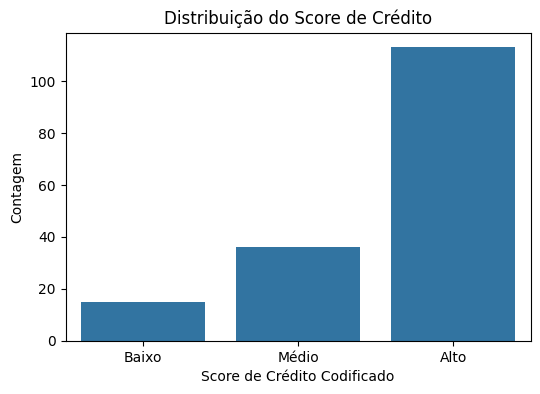

Contagem por classe:
credit_score_encoded
2    113
1     36
0     15
Name: count, dtype: int64

Percentual por classe:
credit_score_encoded
2    68.90
1    21.95
0     9.15
Name: proportion, dtype: float64


In [33]:
order_credit_score = ['Baixo', 'Médio', 'Alto']
map_score = {0: 'Baixo', 1: 'Médio', 2: 'Alto'}

# Convertendo a variável alvo para nomes
y_plot = y.map(map_score)

# Verificando a distribuição da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(x=y_plot, order=order_credit_score)
plt.title('Distribuição do Score de Crédito')
plt.xlabel('Score de Crédito Codificado')
plt.ylabel('Contagem')
plt.show()

print('Contagem por classe:')
print(y.value_counts())

print('\nPercentual por classe:')
print((y.value_counts(normalize=True) * 100).round(2))

Ao observar a distribuição da variável alvo, nota-se que as classes não estão balanceadas. A classe Alto apresenta maior frequência na base, enquanto as classes Baixo e Médio aparecem em menor quantidade. Esse desequilíbrio pode impactar o desempenho do modelo, favorecendo a classe majoritária durante o treinamento.

## 4.5 Realizar o balancecamento dos dados da coluna de credit score

In [34]:
# Aplicando balanceamento apenas na base de treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print('Distribuição antes do balanceamento:')
print(y_train.value_counts())

print('\nDistribuição depois do balanceamento:')
print(y_train_balanced.value_counts())

Distribuição antes do balanceamento:
credit_score_encoded
2    90
1    29
0    12
Name: count, dtype: int64

Distribuição depois do balanceamento:
credit_score_encoded
1    90
2    90
0    90
Name: count, dtype: int64


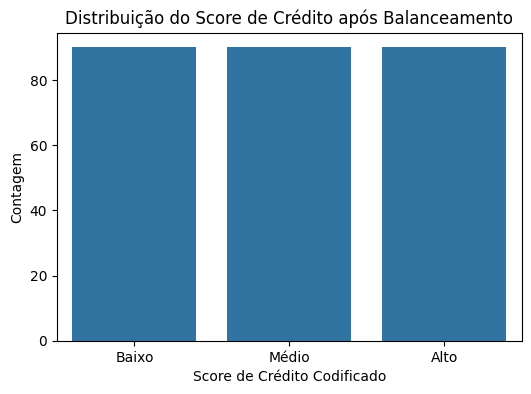

In [35]:
order_credit_score = ['Baixo', 'Médio', 'Alto']
map_score = {0: 'Baixo', 1: 'Médio', 2: 'Alto'}

# Convertendo a variável alvo para nomes
y_train_balanced_plot = plot = y_train_balanced.map(map_score)

# Gráfico para visualizar se o balanceamento funcionou
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_balanced_plot, order=order_credit_score)
plt.title('Distribuição do Score de Crédito após Balanceamento')
plt.xlabel('Score de Crédito Codificado')
plt.ylabel('Contagem')
plt.show()

O balanceamento foi realizado apenas na base de treino, conforme boa prática em machine learning, evitando vazamento de informação da base de teste. Para isso, foi utilizado o método SMOTE, que gera novas amostras sintéticas para as classes minoritárias até equilibrar a distribuição das classes. Esse procedimento ajuda o modelo a aprender de forma mais equilibrada todas as categorias da variável alvo.